In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import time
import random
import numpy as np
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


2026-02-12 04:14:34.890012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770869675.093435      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770869675.151163      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770869675.602917      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770869675.602983      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770869675.602986      55 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
CONFIG = {
    "DATA_DIR": "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24",
    "SAMPLE_RATE": 22050,
    "DURATION": 3,
    "N_MELS": 128,
    "NUM_CLASSES": 8,
    "BATCH_SIZE": 128,
    "EPOCHS": 5,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-4,
    "TEST_SIZE": 0.2,
    "VAL_SIZE": 0.1
}


**Dataset Loading and Preprocessing**

In [4]:
def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=CONFIG["SAMPLE_RATE"])
    max_len = CONFIG["SAMPLE_RATE"] * CONFIG["DURATION"]

    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=CONFIG["N_MELS"]
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


def load_dataset():
    """
    Loads RAVDESS dataset.
    Assumes structure:
    Dataset/Actor_01/03-01-05-...
    """
    X, y = [], []

    for root, _, files in os.walk(CONFIG["DATA_DIR"]):
        for file in files:
            if file.endswith(".wav"):
                emotion = int(file.split("-")[2]) - 1
                path = os.path.join(root, file)

                X.append(extract_features(path))
                y.append(emotion)

    X = np.array(X, dtype=np.float32)
    y = tf.keras.utils.to_categorical(y, CONFIG["NUM_CLASSES"])

    print("Dataset shape:", X.shape)
    return X, y


X, y = load_dataset()

# Normalize
X = (X - np.mean(X)) / np.std(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["TEST_SIZE"],
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=CONFIG["VAL_SIZE"],
    random_state=SEED,
    stratify=y_train
)

# CNN input
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]


Dataset shape: (1440, 128, 130)


**Baseline Models**

In [8]:
def build_baseline_mlp(input_shape):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(CONFIG["NUM_CLASSES"], activation='softmax')
    ])


In [9]:
def build_baseline_cnn(input_shape):
    return models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(CONFIG["NUM_CLASSES"], activation='softmax')
    ])


In [10]:
def build_optimized_mlp(input_shape):

    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x1 = layers.Dense(512, kernel_initializer='he_normal')(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)
    x1 = layers.Dropout(0.4)(x1)
    x2 = layers.Dense(512, kernel_initializer='he_normal')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)
    x = layers.Add()([x1, x2])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(CONFIG["NUM_CLASSES"],
                           activation='softmax',
                           dtype='float32')(x)

    return models.Model(inputs, outputs)


**Optimized Models**

In [11]:
def build_optimized_cnn(input_shape):

    data_aug = tf.keras.Sequential([
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
    ])

    inputs = layers.Input(shape=input_shape)
    x = data_aug(inputs)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3,
                          padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(CONFIG["NUM_CLASSES"],
                           activation='softmax',
                           dtype='float32')(x)

    return models.Model(inputs, outputs)


**Compiling and Training**

In [15]:
def compile_and_train(model, X_tr, y_tr, X_v, y_v, optimized=False):

    if optimized:
        try:
            from tensorflow.keras.optimizers import AdamW
            optimizer = AdamW(
                learning_rate=CONFIG["LR"],
                weight_decay=CONFIG["WEIGHT_DECAY"]
            )
        except:
            optimizer = tf.keras.optimizers.Adam(CONFIG["LR"])
    else:
        optimizer = tf.keras.optimizers.Adam(CONFIG["LR"])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = []
    if optimized:
        callbacks = [
            EarlyStopping(patience=4, restore_best_weights=True),
            ReduceLROnPlateau(patience=2)
        ]

    start = time.time()

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=CONFIG["EPOCHS"],
        batch_size=CONFIG["BATCH_SIZE"],
        verbose=1,
        callbacks=callbacks
    )

    train_time = time.time() - start
    return history, train_time


In [16]:
results = {}

def run_experiment(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, optimized=False):

    print(f"\nTraining {name}...\n")

    history, train_time = compile_and_train(
        model, X_tr, y_tr, X_v, y_v, optimized
    )

    test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)

    results[name] = {
    "history": history.history,
    "train_time": train_time,
    "test_accuracy": test_acc,
    "params": model.count_params(),
    "model": model  
}



In [17]:
run_experiment("Baseline_MLP",
               build_baseline_mlp(X_train.shape[1:]),
               X_train, y_train, X_val, y_val, X_test, y_test)

run_experiment("Baseline_CNN",
               build_baseline_cnn(X_train_cnn.shape[1:]),
               X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test)

run_experiment("Optimized_MLP",
               build_optimized_mlp(X_train.shape[1:]),
               X_train, y_train, X_val, y_val, X_test, y_test,
               optimized=True)

run_experiment("Optimized_CNN",
               build_optimized_cnn(X_train_cnn.shape[1:]),
               X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test,
               optimized=True)




Training Baseline_MLP...

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.1423 - loss: 7.8851 - val_accuracy: 0.1293 - val_loss: 10.3019
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1496 - loss: 10.1508 - val_accuracy: 0.1293 - val_loss: 13.7384
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1385 - loss: 13.0409 - val_accuracy: 0.1724 - val_loss: 12.2152
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1977 - loss: 12.0007 - val_accuracy: 0.1466 - val_loss: 12.5300
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1847 - loss: 12.1036 - val_accuracy: 0.1466 - val_loss: 13.1030

Training Baseline_CNN...

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step - accuracy: 0.1293 - loss: 5.7871 - val_accuracy: 0.1293 - val_loss: 7.6488
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1409 - loss: 7.3051 - val_accuracy: 0.1379 - val_loss: 4.4897
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1787 

**Hyperparameter Tuning**

In [18]:
lr_values = [1e-2, 1e-3, 1e-4]

for lr in lr_values:
    CONFIG["LR"] = lr
    CONFIG["EPOCHS"] = 5
    
    run_experiment(f"Optimized_CNN_LR_{lr}",
                   build_optimized_cnn(X_train_cnn.shape[1:]),
                   X_train_cnn, y_train,
                   X_val_cnn, y_val,
                   X_test_cnn, y_test,
                   optimized=True)



Training Optimized_CNN_LR_0.01...

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1344 - loss: 2.8004 - val_accuracy: 0.1293 - val_loss: 17.5822 - learning_rate: 0.0100
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.1384 - loss: 2.0757 - val_accuracy: 0.1379 - val_loss: 14.8216 - learning_rate: 0.0100
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.1473 - loss: 2.0645 - val_accuracy: 0.1379 - val_loss: 13.9481 - learning_rate: 0.0100
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.1499 - loss: 2.0417 - val_accuracy: 0.1293 - val_loss: 13.0315 - learning_rate: 0.0100
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.1516 - loss: 2.0377 - val_accuracy: 0.1293 - val_loss: 10.7938 - learning_rate: 0.0100

Training Optimized_CNN_LR_0.001...

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1303 - loss: 2.2135 - val_accuracy: 0.1552 - val_loss: 3.1608 - learning_rate: 0.0010
Epoch 2/5
9/9 ━━━━━━━━━━━━━━

In [19]:
batch_sizes = [32, 64, 128]

for bs in batch_sizes:
    CONFIG["BATCH_SIZE"] = bs
    CONFIG["LR"] = 1e-3
    CONFIG["EPOCHS"] = 5
    
    run_experiment(f"Optimized_CNN_BS_{bs}",
                   build_optimized_cnn(X_train_cnn.shape[1:]),
                   X_train_cnn, y_train,
                   X_val_cnn, y_val,
                   X_test_cnn, y_test,
                   optimized=True)



Training Optimized_CNN_BS_32...

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.1554 - loss: 2.1986 - val_accuracy: 0.1293 - val_loss: 3.3823 - learning_rate: 0.0010
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2577 - loss: 1.9426 - val_accuracy: 0.1293 - val_loss: 2.9694 - learning_rate: 0.0010
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3098 - loss: 1.8270 - val_accuracy: 0.1724 - val_loss: 3.3324 - learning_rate: 0.0010
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3338 - loss: 1.7701 - val_accuracy: 0.1983 - val_loss: 3.8269 - learning_rate: 0.0010
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3270 - loss: 1.7560 - val_accuracy: 0.2328 - val_loss: 3.0269 - learning_rate: 1.0000e-04

Training Optimized_CNN_BS_64...

Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.1391 - loss: 2.2340 - val_accuracy: 0.1293 - val_loss: 3.1409 - learning_rate: 0.0010
Epoch 2/5
17/17 ━━━━━━━━━━

In [20]:
tuning_results = []

for name in results:
    if "LR" in name or "BS" in name:
        tuning_results.append([
            name,
            results[name]["params"],
            round(results[name]["train_time"], 2),
            round(results[name]["test_accuracy"], 4)
        ])

tuning_df = pd.DataFrame(tuning_results,
                         columns=["Experiment",
                                  "Parameters",
                                  "Training Time (s)",
                                  "Test Accuracy"])

print(tuning_df)


                Experiment  Parameters  Training Time (s)  Test Accuracy
0    Optimized_CNN_LR_0.01      128648               9.79         0.1354
1   Optimized_CNN_LR_0.001      128648               9.75         0.1562
2  Optimized_CNN_LR_0.0001      128648               9.73         0.1354
3      Optimized_CNN_BS_32      128648              14.39         0.1354
4      Optimized_CNN_BS_64      128648              15.23         0.1944
5     Optimized_CNN_BS_128      128648               9.85         0.1354


**Visualization**

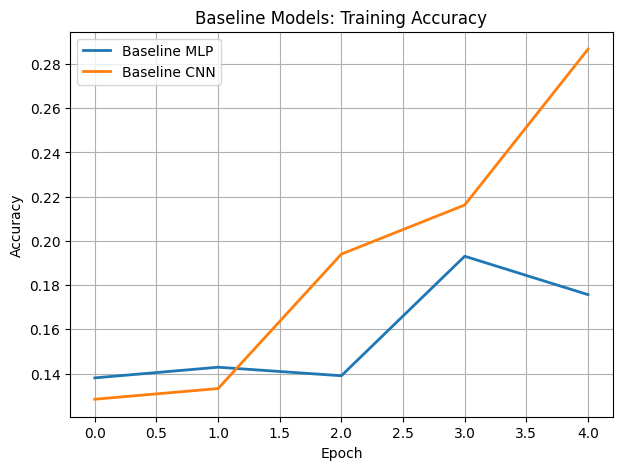

In [21]:
plt.figure(figsize=(7,5))

plt.plot(results["Baseline_MLP"]["history"]["accuracy"],
         label="Baseline MLP",
         linewidth=2)

plt.plot(results["Baseline_CNN"]["history"]["accuracy"],
         label="Baseline CNN",
         linewidth=2)

plt.title("Baseline Models: Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


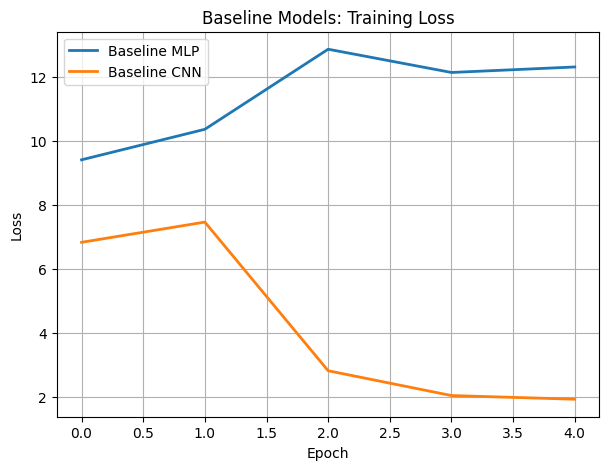

In [22]:
plt.figure(figsize=(7,5))

plt.plot(results["Baseline_MLP"]["history"]["loss"],
         label="Baseline MLP",
         linewidth=2)

plt.plot(results["Baseline_CNN"]["history"]["loss"],
         label="Baseline CNN",
         linewidth=2)

plt.title("Baseline Models: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


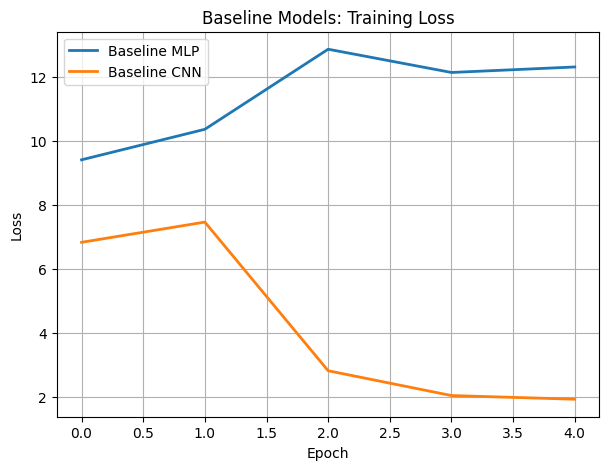

In [23]:
plt.figure(figsize=(7,5))

plt.plot(results["Baseline_MLP"]["history"]["loss"],
         label="Baseline MLP",
         linewidth=2)

plt.plot(results["Baseline_CNN"]["history"]["loss"],
         label="Baseline CNN",
         linewidth=2)

plt.title("Baseline Models: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


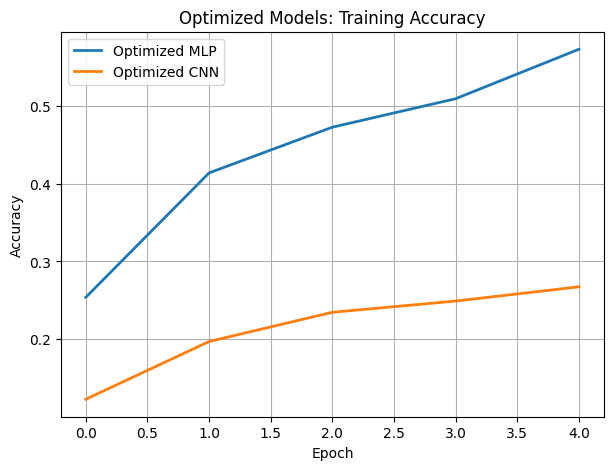

In [24]:
plt.figure(figsize=(7,5))

plt.plot(results["Optimized_MLP"]["history"]["accuracy"],
         label="Optimized MLP",
         linewidth=2)

plt.plot(results["Optimized_CNN"]["history"]["accuracy"],
         label="Optimized CNN",
         linewidth=2)

plt.title("Optimized Models: Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


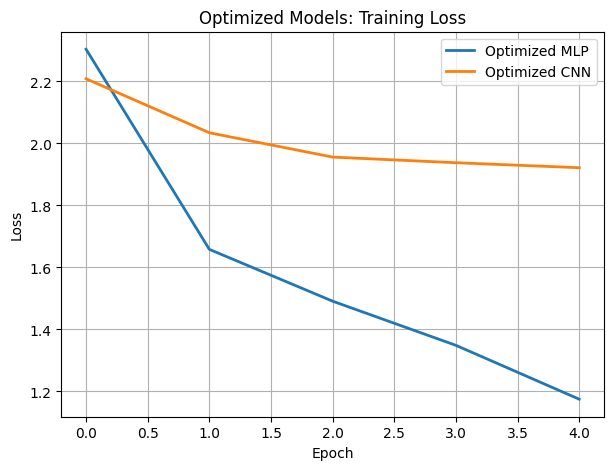

In [25]:
plt.figure(figsize=(7,5))

plt.plot(results["Optimized_MLP"]["history"]["loss"],
         label="Optimized MLP",
         linewidth=2)

plt.plot(results["Optimized_CNN"]["history"]["loss"],
         label="Optimized CNN",
         linewidth=2)

plt.title("Optimized Models: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


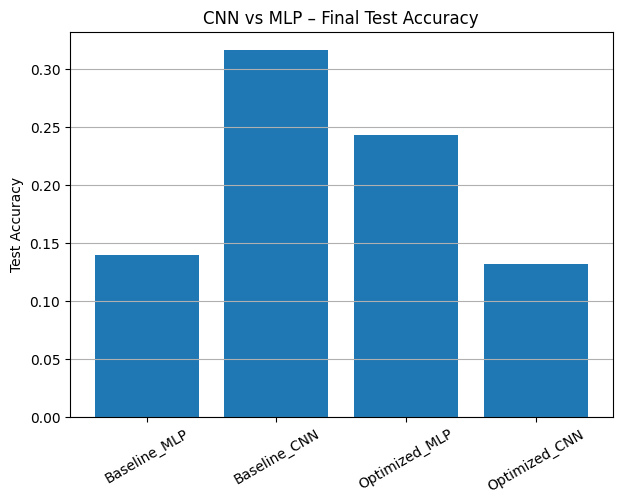

In [26]:
models = ["Baseline_MLP",
          "Baseline_CNN",
          "Optimized_MLP",
          "Optimized_CNN"]

accuracies = [results[m]["test_accuracy"] for m in models]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylabel("Test Accuracy")
plt.title("CNN vs MLP – Final Test Accuracy")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()


In [27]:
summary = []
for name in results:
    summary.append([
        name,
        results[name]["params"],
        round(results[name]["train_time"], 2),
        round(results[name]["test_accuracy"], 4)
    ])

df = pd.DataFrame(summary,
                  columns=["Model",
                           "Parameters",
                           "Training Time (s)",
                           "Test Accuracy"])

print(df)


                     Model  Parameters  Training Time (s)  Test Accuracy
0             Baseline_MLP     4294024               4.46         0.1389
1             Baseline_CNN     7638536               7.07         0.3160
2            Optimized_MLP     8920328               9.79         0.2431
3            Optimized_CNN      128648              10.23         0.1319
4    Optimized_CNN_LR_0.01      128648               9.79         0.1354
5   Optimized_CNN_LR_0.001      128648               9.75         0.1562
6  Optimized_CNN_LR_0.0001      128648               9.73         0.1354
7      Optimized_CNN_BS_32      128648              14.39         0.1354
8      Optimized_CNN_BS_64      128648              15.23         0.1944
9     Optimized_CNN_BS_128      128648               9.85         0.1354


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


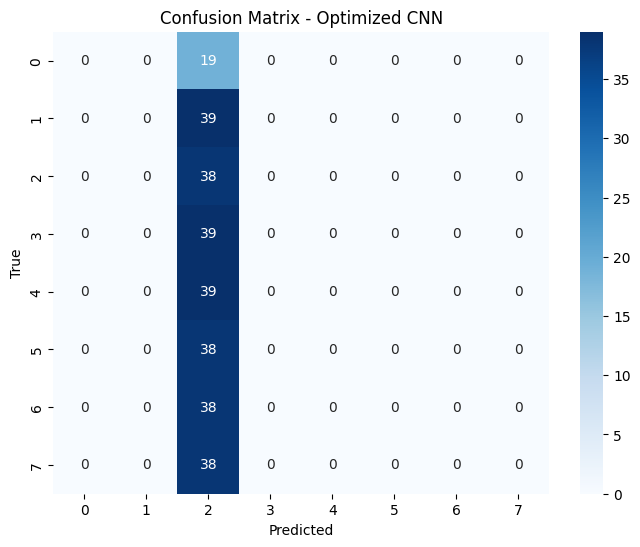

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = results["Optimized_CNN"]["model"]

y_pred = np.argmax(best_model.predict(X_test_cnn), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Optimized CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
